## Build a basic chatbot with Langgraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages # called as reducers


In [2]:
class State(TypedDict): 
    # messages have the type :list" . The `add messages` fucntion
    # in the annotation it defines how this state should be updated
    # in this case, it appends messages to the list, rather than overwriting them
    messages : Annotated[list, add_messages]

graphbuilder = StateGraph(State)
graphbuilder

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0.9,
    api_key = os.getenv("GROQ_API_KEY")
 )

In [5]:
def chatbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [6]:
graphbuilder = StateGraph(State)
graphbuilder.add_node("llmchatbot",chatbot)
graphbuilder.add_edge(START,"llmchatbot")
graphbuilder.add_edge("llmchatbot",END)

#compile the graph to a function that can be called with the initial state
graph = graphbuilder.compile()



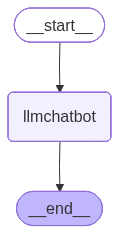

In [7]:
##visualise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualisation failed:", e)

In [8]:
response = graph.invoke({"messages": ["Hello, how are you?"]})

In [9]:
print(response["messages"][0].content)
print(response["messages"][-1].content)

Hello, how are you?
I'm just a language model, so I don't have emotions or feelings in the way that humans do. However, I'm functioning properly and ready to help you with any questions or tasks you may have. How can I assist you today?


In [10]:
for event in graph.stream({"messages": "Hello, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello. I'm functioning properly, thank you for asking. Is there anything I can help you with or provide information on?


CHATBOT WITH TOOL

In [11]:
##tool to be created TAVLIY SEARCH FOR WEB SEARCH
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results=3)
tool.invoke("What is the capital of France?")


{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
   'title': 'Paris facts: the capital of France in history',
   'content': '## Paris facts: Paris, the **capital of France**. Paris is the **capital of France**, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. ## Paris facts: Paris history. From the Romans to the Vth Republic, Paris has a rich 2000 year history. See details of Paris history. ## Paris facts: Paris, a world city. Paris is a world capital city of shopping and fashion, with Channel, Dior, Vuitton, Yves Saint Laurent among many other top french fashion brands. ## Paris facts: the capital of France in history. Before Paris, the capital of France was Lyon (under the Romans). Paris first became the capital of France in 508 under King Clovis. After centuries with no unique capital o

In [12]:
def multiply(x: int, y: int) -> int:
    """Multiplies two numbers together.
    Args:
        x: The first number.
        y: The second number.
    Returns:
        The product of x and y.
    """
    return x * y

In [13]:
tools = [tool,multiply]
llm_with_tools = llm.bind_tools(tools)

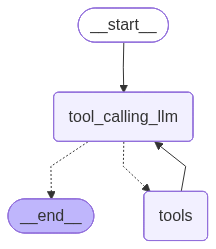

In [14]:
 ## stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
config = {"configurable": {"thread_id": "1"}}

## node defination
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")  # ← loop back, not END

tool_graph = builder.compile(checkpointer=memory)
##visualise the graph
from IPython.display import Image,display
try:
    display(Image(tool_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualisation failed:", e)


In [15]:
response = tool_graph.invoke({"messages": "what is the latest news in ai and then multiply 5 by 10?"},config=config)

In [16]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the latest news in ai and then multiply 5 by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rbn49p3k8)
 Call ID: rbn49p3k8
  Args:
    query: latest AI news
    time_range: day
    topic: news
  multiply (sts06htfs)
 Call ID: sts06htfs
  Args:
    x: 5
    y: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.thestreet.com/latest-news/ai-is-getting-worse-as-google-and-anthropic-nerf-ai-models-and-limit-usage", "title": "AI is getting worse as Google and Anthropic nerf AI models and limit usage - thestreet.com", "score": 0.99135584, "published_date": "Sun, 24 May 2026 17:12:00 GMT", "content": "# AI is getting worse as Google and Anthropic nerf AI models and lim

In [17]:

response = tool_graph.invoke({"messages": "my name is Samarth"}, config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the latest news in ai and then multiply 5 by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rbn49p3k8)
 Call ID: rbn49p3k8
  Args:
    query: latest AI news
    time_range: day
    topic: news
  multiply (sts06htfs)
 Call ID: sts06htfs
  Args:
    x: 5
    y: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.thestreet.com/latest-news/ai-is-getting-worse-as-google-and-anthropic-nerf-ai-models-and-limit-usage", "title": "AI is getting worse as Google and Anthropic nerf AI models and limit usage - thestreet.com", "score": 0.99135584, "published_date": "Sun, 24 May 2026 17:12:00 GMT", "content": "# AI is getting worse as Google and Anthropic nerf AI models and lim

In [18]:
response = tool_graph.invoke({"messages": "what is my name?"}, config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the latest news in ai and then multiply 5 by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rbn49p3k8)
 Call ID: rbn49p3k8
  Args:
    query: latest AI news
    time_range: day
    topic: news
  multiply (sts06htfs)
 Call ID: sts06htfs
  Args:
    x: 5
    y: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.thestreet.com/latest-news/ai-is-getting-worse-as-google-and-anthropic-nerf-ai-models-and-limit-usage", "title": "AI is getting worse as Google and Anthropic nerf AI models and limit usage - thestreet.com", "score": 0.99135584, "published_date": "Sun, 24 May 2026 17:12:00 GMT", "content": "# AI is getting worse as Google and Anthropic nerf AI models and lim

## STREAMING

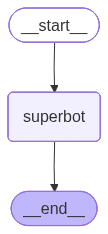

In [19]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

def superbot(State):
    return {"messages": [llm.invoke(State["messages"])]} 

graph = StateGraph(State)
graph.add_node("superbot", superbot)
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph = graph.compile(checkpointer=memory)

from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualisation failed:", e)


## Streaming

Methods: stream() and astream()
-These methods are sync and async methods for streaming back results
Additional paramters in streaming modes for graph state
- values : this streams the full state of the graph after each node is called.
- updates: this streams updates to the state of the graph after each node is called.

In [20]:
config = {"configurable": {"thread_id": "3"}}

for chunk in graph.stream({"messages": "hi im samarth and i like to sleep"}, config=config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Nice to meet you, Samarth. It sounds like you enjoy a good sleep. Sleeping is essential for our bodies and minds to recharge. How many hours of sleep do you like to get each night?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 44, 'total_tokens': 86, 'completion_time': 0.118934881, 'completion_tokens_details': None, 'prompt_time': 0.003165626, 'prompt_tokens_details': None, 'queue_time': 0.049803094, 'total_time': 0.122100507}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5e86-b427-73f0-bd8b-9c5eb714ce3e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 42, 'total_tokens': 86})]}}


In [21]:
config = {"configurable": {"thread_id": "3"}}

for chunk in graph.stream({"messages": "what are the best laptops availabe in the market"}, config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi im samarth and i like to sleep', additional_kwargs={}, response_metadata={}, id='e82ed903-4a07-4f62-aa77-f6f3a43bf602'), AIMessage(content='Nice to meet you, Samarth. It sounds like you enjoy a good sleep. Sleeping is essential for our bodies and minds to recharge. How many hours of sleep do you like to get each night?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 44, 'total_tokens': 86, 'completion_time': 0.118934881, 'completion_tokens_details': None, 'prompt_time': 0.003165626, 'prompt_tokens_details': None, 'queue_time': 0.049803094, 'total_time': 0.122100507}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5e86-b427-73f0-bd8b-9c5eb714ce3e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 42, 'total_tok

In [ ]:
config = {"configurable": {"thread_id": "4"}}

for chunk in graph.stream({"messages": "Hi my name is samarth and i like basketball"}, config=config,stream_mode="updates"):
    print(chunk)

In [ ]:

for chunk in graph.stream({"messages": "I also like football"}, config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is samarth and i like basketball', additional_kwargs={}, response_metadata={}, id='3b6c5724-d266-4f9f-8b8e-841d8398c1a6'), AIMessage(content="Nice to meet you, Samarth. Basketball is an amazing sport, isn't it? The combination of speed, agility, and teamwork makes it both physically and mentally challenging. Who's your favorite basketball player of all time?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 45, 'total_tokens': 91, 'completion_time': 0.240847592, 'completion_tokens_details': None, 'prompt_time': 0.058068526, 'prompt_tokens_details': None, 'queue_time': 0.08782988, 'total_time': 0.298916118}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4f4a-be0c-7243-abb6-c47685b17809-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inp

astream example

In [ ]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph.astream_events({"messages": "Hi my name is samarth and i like basketball"}, config=config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is samarth and i like basketball'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e4f4a-e40b-7e92-be6d-b2aa565f7414', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is samarth and i like basketball', additional_kwargs={}, response_metadata={}, id='d06e00e3-03e1-4f2b-813b-ad602560cd74')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019e4f4a-e40d-7661-bb91-8f3a6d04ba73', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:e65a77f4-ab1f-54b1-24b9-f0dab7899e35'}, 'parent_ids': ['019e4f4a-e40b-7e92-be6d-b2aa565f7414']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[Human

## Human in the loop

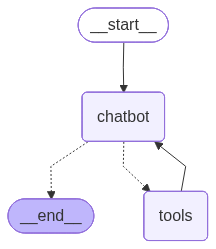

In [ ]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages # called as reducers
from langgraph.prebuilt import ToolNode,tools_condition

from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt,Command


class State(TypedDict): 
    messages : Annotated[list, add_messages]

graphbuilder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Use this tool to ask the human for help when the question is too difficult for the LLM."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=3)
tools = [tool,human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state:State):
    messages = llm_with_tools.invoke(state["messages"])
    #because w will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any tool calls during the interruption
    return {"messages": [messages]}

graphbuilder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools)
graphbuilder.add_node("tools", tool_node)

graphbuilder.add_conditional_edges("chatbot", tools_condition)
graphbuilder.add_edge("tools", "chatbot")  # ← loop back, not END
graphbuilder.add_edge(START,"chatbot")

graph = graphbuilder.compile(checkpointer=MemorySaver())

from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualisation failed:", e)





memory = MemorySaver()

In [ ]:
user_query = "I need some expert guidance for building an AI agent. Could you request assistance for me?"

config = {"configurable": {"thread_id": "6"}}

events = graph.stream({"messages": user_query}, config=config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (0twtc52pj)
 Call ID: 0twtc52pj
  Args:
    query: request guidance from AI expert on building an agent
================================== Ai Message ==================================
Tool Calls:
  human_assistance (0twtc52pj)
 Call ID: 0twtc52pj
  Args:
    query: request guidance from AI expert on building an agent


In [ ]:
human_response = ("We, the experts are here to help, we'd recommend you to check out langgraph to build your agent."
                  "Its much more reliable and extensible than simple autonomous agents!")

human_command = Command(resume={"data":human_response})

events = graph.stream(human_command,config=config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (hwnbpj54p)
 Call ID: hwnbpj54p
  Args:
    query: recommend AI development tools for building an agent
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help, we'd recommend you to check out langgraph to build your agent.Its much more reliable and extensible than simple autonomous agents!
================================== Ai Message ==================================
Tool Calls:
  human_assistance (p7857mh2k)
 Call ID: p7857mh2k
  Args:
    query: suggestion for langgraph usage in building an AI agent
================================== Ai Message ==================================
Tool Calls:
  human_assistance (p7857mh2k)
 Call ID: p7857mh2k
  Args:
    query: suggestion for langgraph usage in building an AI agent
